# Week 7 · Day 2 — Support Vector Machines: The Widest Street

We've separated classes with logistic regression — it draws *a* line between them. Today's model, the **Support Vector Machine (SVM)**, asks a smarter question: not just "a line that separates the classes," but **"the line that separates them with the widest possible gap."**

That one idea — the *widest gap* — makes SVMs one of the most powerful classical classifiers. And with the **kernel trick**, they can even draw *curved* boundaries for data a straight line could never split.

**The plan:**
1. The big idea — the widest street, and support vectors.
2. SVM in scikit-learn — see the boundary, margins, and support vectors.
3. The kernel trick — curved boundaries for tricky data.
4. Tuning the two knobs, and evaluating.

*(New this week: we go straight to scikit-learn. You already know the workflow — fit, predict, evaluate — so the new learning is what each model does, not how to code it from scratch.)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

---
## 1. The big idea: the widest street

Suppose two classes of points sit clearly apart. **Many** different straight lines could separate them — a line tilted slightly left, slightly right, closer to one group or the other. They all get the job done on the training data. So which line is *best*?

SVM's answer: the line with the **largest margin**. Picture widening a *street* between the two groups — pushing the edges apart — until the street just touches the nearest points on each side. The line running down the *middle* of the widest possible street is the SVM's boundary.

The few points that the street's edges touch are called the **support vectors**. Here's the striking part: **those points alone define the boundary.** A point far from the street could be moved around freely and nothing changes — but move a support vector, and the whole boundary shifts. The name "support vector machine" comes from these supporting points.

**Why a wide margin is good:** it's the most *confident*, most *robust* separator. Leaving the biggest possible buffer between the classes means new, unseen points are less likely to fall on the wrong side. Let's see it.

---
## 2. SVM in scikit-learn — seeing the margin

We'll make two clearly-separated groups and fit a linear SVM. The API is the same four steps you know: create, `.fit()`, `.predict()`, score.

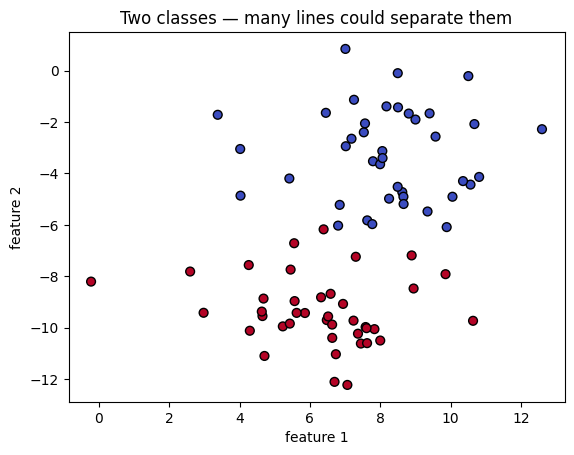

In [2]:
from sklearn.datasets import make_blobs

# two separated clusters
X, y = make_blobs(n_samples=80, centers=2, random_state=6, cluster_std=1.8)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=40, edgecolor="k")
plt.title("Two classes — many lines could separate them")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

In [3]:
# train a linear SVM
model = SVC(kernel="linear", C=1)
model.fit(X, y)

print("accuracy on training data:", model.score(X, y))
print("number of support vectors:", len(model.support_vectors_))

accuracy on training data: 0.9875
number of support vectors: 6


Now the key picture. We draw the **decision boundary** (solid line), the **margins** (dashed lines — the edges of the street), and circle the **support vectors** (the points touching the margins that define everything).

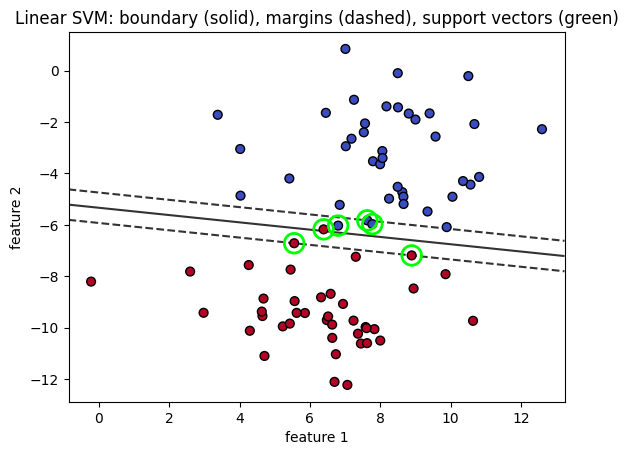

In [4]:
def plot_svm(model, X, y, title=""):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=40, edgecolor="k", zorder=3)
    ax = plt.gca()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    # grid to evaluate the decision function on
    xx = np.linspace(xlim[0], xlim[1], 50)
    yy = np.linspace(ylim[0], ylim[1], 50)
    YY, XX = np.meshgrid(yy, xx)
    Z = model.decision_function(np.vstack([XX.ravel(), YY.ravel()]).T).reshape(XX.shape)

    # boundary (level 0) and margins (levels -1, +1)
    ax.contour(XX, YY, Z, colors="k", levels=[-1, 0, 1],
               linestyles=["--", "-", "--"], alpha=0.8)
    # circle the support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=200, facecolors="none", edgecolors="lime", linewidths=2, zorder=4)
    plt.title(title); plt.xlabel("feature 1"); plt.ylabel("feature 2")
    plt.show()

plot_svm(model, X, y, "Linear SVM: boundary (solid), margins (dashed), support vectors (green)")

There it is:
- the **solid line** is the decision boundary,
- the **dashed lines** are the margins — the edges of the widest street,
- the **green-circled points** are the support vectors, sitting exactly on the margins.

Notice how few support vectors there are. Every other point could be ignored entirely and the boundary would be identical. The SVM found the widest street it could fit between the two classes.

### Compare with logistic regression
On separable data like this, logistic regression finds a similar boundary — but it isn't *deliberately* maximizing the margin. SVM's boundary is placed with intent: the biggest possible buffer. Different models, different reasoning, often similar results.

In [5]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X, y)
print("logistic regression accuracy:", logreg.score(X, y))
print("SVM accuracy:               ", model.score(X, y))
print("\nBoth separate the data — SVM just does it with the widest margin.")

logistic regression accuracy: 0.9875
SVM accuracy:                0.9875

Both separate the data — SVM just does it with the widest margin.


---
## 3. The kernel trick: curved boundaries

Everything so far used a **straight** line. But what if the classes can't be separated by any straight line? The classic example: one class forms a **ring around** the other. No straight line can split a donut from its hole.

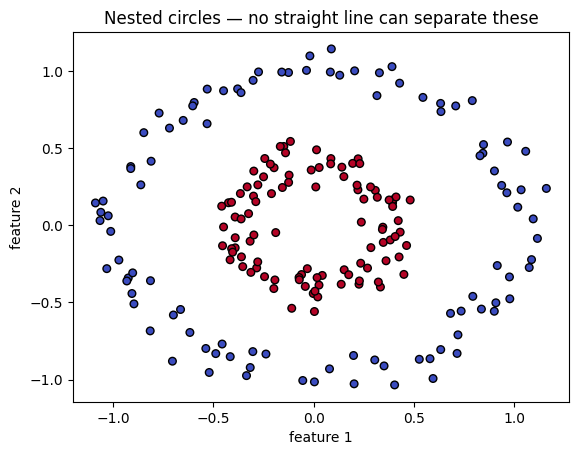

In [6]:
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=1)

plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", s=30, edgecolor="k")
plt.title("Nested circles — no straight line can separate these")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

Let's prove a straight line fails here — fit a **linear** SVM and check its accuracy.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=1)

linear_svm = SVC(kernel="linear").fit(Xtr, ytr)
print("linear kernel accuracy:", accuracy_score(yte, linear_svm.predict(Xte)))

linear kernel accuracy: 0.45


Around 45% — **worse than flipping a coin.** A straight line is hopeless here.

### The trick
SVM's **kernel trick** solves this. The intuition: if the data can't be split by a flat line in 2D, **lift it into a higher dimension** where it *can* be split by a flat surface, draw the separator there, then project it back down — where it appears as a *curve*.

The metaphor: *two colours of marbles are mixed flat on a table, impossible to split with a ruler. But lift the inner-circle marbles up onto a shelf — now a flat sheet of paper slides cleanly between the two heights.* The kernel does this lifting automatically.

We switch one word — `kernel="rbf"` (the most common kernel) — and refit.

In [8]:
rbf_svm = SVC(kernel="rbf").fit(Xtr, ytr)
print("RBF kernel accuracy:", accuracy_score(yte, rbf_svm.predict(Xte)))

RBF kernel accuracy: 1.0


**100%** — a perfect split, just by changing the kernel. Let's *see* the curved boundary it drew.

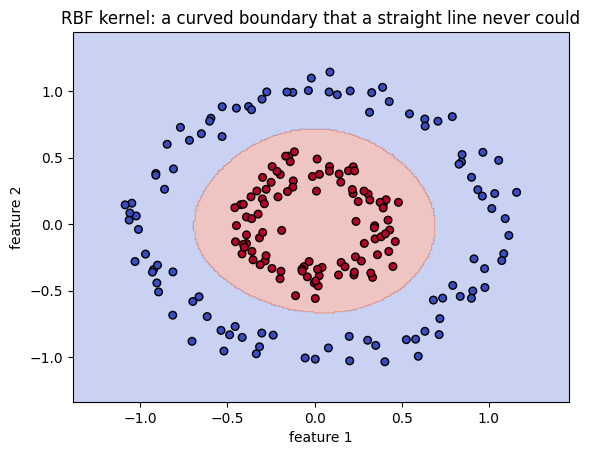

In [9]:
def plot_boundary(model, X, y, title=""):
    xx = np.linspace(X[:, 0].min()-0.3, X[:, 0].max()+0.3, 300)
    yy = np.linspace(X[:, 1].min()-0.3, X[:, 1].max()+0.3, 300)
    XX, YY = np.meshgrid(xx, yy)
    Z = model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    plt.contourf(XX, YY, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=30, edgecolor="k")
    plt.title(title); plt.xlabel("feature 1"); plt.ylabel("feature 2")
    plt.show()

plot_boundary(rbf_svm, Xc, yc, "RBF kernel: a curved boundary that a straight line never could")

The RBF kernel wrapped a **circular boundary** around the inner class — exactly the shape the data needed. This is the real power of SVMs: with the right kernel, they draw whatever boundary shape the problem demands.

---
## 4. The two knobs: C and gamma

SVMs have two main settings you'll actually adjust:

- **C** — how much to punish mistakes. **High C** tries hard to classify every training point correctly (narrow margin, risk of overfitting); **low C** allows some mistakes for a wider, simpler margin.
- **gamma** (for RBF) — how wiggly the boundary can be. **High gamma** lets the boundary twist tightly around individual points (risk of overfitting); **low gamma** keeps it smooth.

Let's watch **gamma** overfit, live — the same overfitting lesson from last week, now with SVM.

In [10]:
# noisier circles so overfitting is visible
Xn, yn = make_circles(n_samples=150, noise=0.18, factor=0.5, random_state=3)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.3, random_state=3)

print("gamma :  train acc  test acc")
for g in [0.5, 2, 50]:
    m = SVC(kernel="rbf", gamma=g).fit(Xn_tr, yn_tr)
    print(f"  {g:<5} :   {m.score(Xn_tr, yn_tr):.2f}      {m.score(Xn_te, yn_te):.2f}")

gamma :  train acc  test acc
  0.5   :   0.92      0.89
  2     :   0.94      0.87
  50    :   1.00      0.91


See the pattern: at **gamma=50** the training accuracy hits 1.00 but the test accuracy *drops* — the boundary has twisted itself around every training point, including the noise. That gap between train and test is **overfitting**, exactly as we saw with high-degree polynomials. The lesson recurs across every model: *more flexibility isn't always better; it must be tuned.*

---
## 5. Evaluating an SVM

An SVM is judged with the **same tools** as every classifier — accuracy, confusion matrix, classification report. Nothing new to learn; the toolkit you built for logistic regression transfers directly.

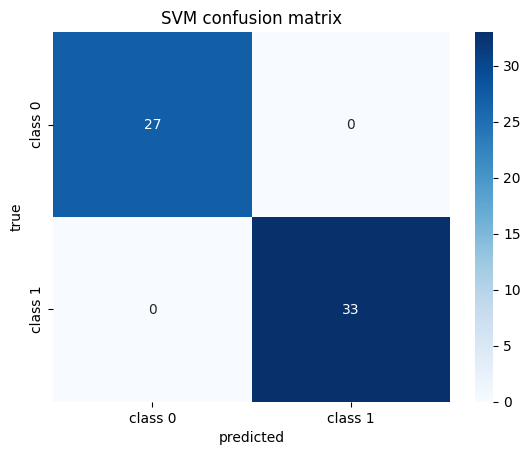

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        33

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# use the good RBF model on the clean circles
predictions = rbf_svm.predict(Xte)

cm = confusion_matrix(yte, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["class 0", "class 1"], yticklabels=["class 0", "class 1"])
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("SVM confusion matrix")
plt.show()

print(classification_report(yte, predictions))

---
## Summary

- An **SVM** separates classes with the **widest possible margin** — the "widest street" between them.
- The points touching the margins are the **support vectors**, and they *alone* define the boundary.
- A wide margin is a confident, robust separator — better at handling new, unseen points.
- The **kernel trick** lets SVMs draw **curved** boundaries: it lifts data into a higher dimension where a flat separator works, then projects back down. Switching `kernel="linear"` → `kernel="rbf"` turned a hopeless 45% into a perfect 100% on nested circles.
- Two knobs to tune: **C** (tolerance for mistakes) and **gamma** (boundary wiggliness). Too high → overfitting, the recurring lesson.
- SVMs are evaluated with the **same** confusion matrix / precision / recall / F1 as every classifier.

Next time: **Decision Trees and Random Forests** — a completely different, wonderfully readable way to classify, by asking a series of yes/no questions.